This notebook applies the Conveyal Estimated LTS framework (Conveyal 2015; Mekuria et al. 2012), augmented by Jeong & Smith (2025), to the Northern Ireland road network extracted from OpenStreetMap.

**Purpose:** classify every cyclable road segment in Northern Ireland by Level of Traffic Stress (LTS 1–4), producing a labelled network ready for downstream Conveyal analysis, routing, and accessibility modelling.

## Methodology overview

The pipeline implements three core stages:

1. **OSM network extraction** — download the full road network via OSMnx, filter to cyclable highway types, and save as GeoParquet
2. **Cycle infrastructure classification** — derive 6 categories (Protected a/b/c, Unprotected Mandatory, Unprotected Advisory, Off-Road) from OSM tags following Jeong & Smith (2025) Table 1
3. **Level of Traffic Stress (LTS)** — augmented Conveyal-based scheme with Routino fallback, cycle infrastructure override, and signalised junction adjustment

## References

- Jeong, P. & Smith, D. (2025). *Improving Infrastructure and Accessibility Indicators for Urban Cycling Networks.* CASA Working Paper 242.
- Mekuria, M. C., Furth, P. G., & Nixon, H. (2012). *Low-Stress Bicycling and Network Connectivity.* MTI Report 11-19.
- Conveyal (2015). *Cycling Level of Traffic Stress.*
- Department for Transport (2020). *LTN 1/20: Cycle Infrastructure Design.*

## Environment setup

In [9]:
import os
from pathlib import Path
import geopandas as gpd

# Mount Google Drive to access project files
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path('/content/drive/MyDrive/PCTNI')

CODE_DIR = PROJECT_ROOT / "Code"
DATA_DIR = PROJECT_ROOT / "Data"
FIGURE_DIR = PROJECT_ROOT / "Figure"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

file_path = DATA_DIR / "zones_sdz.gpkg"

if file_path.exists():
    # Load the Northern Ireland 2021 Super Data Zones (SDZ)
    raw_data = gpd.read_file(file_path, engine="pyogrio")
    print(f"Success: Loaded {len(raw_data)} spatial features.")

    # Optional: Display the first few rows to verify the data
    # print(raw_data.head())
else:
    print(f"Critical Error: File not found at {file_path.absolute()}")
    print("Please verify that the file exists in your Google Drive 'Data' folder.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Success: Loaded 850 spatial features.


## Study area

Northern Ireland, using 2021 Super Data Zones (SDZ) as the spatial unit. All spatial operations use Irish Grid (EPSG:29903).

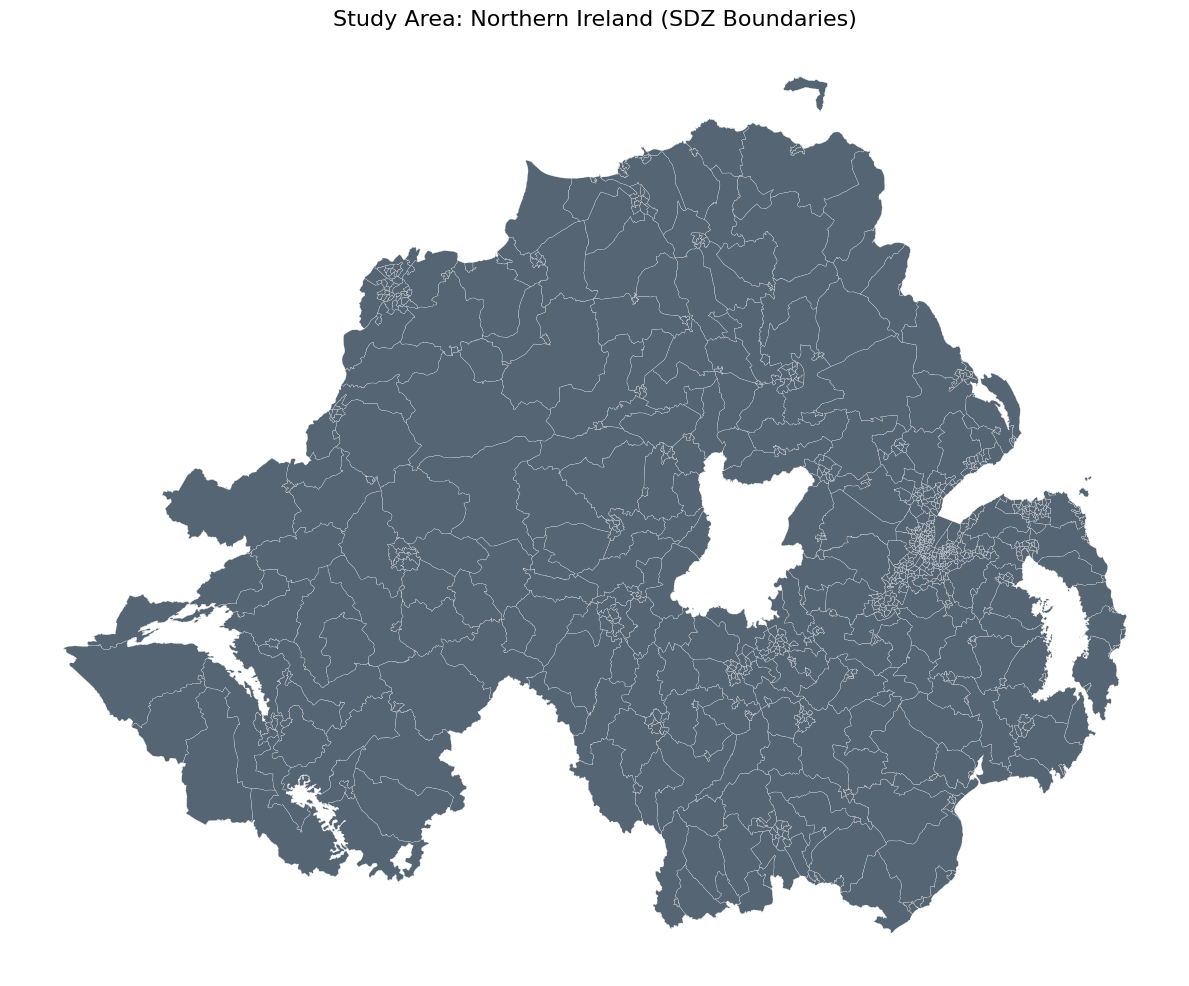


Total study area: 13628.3 km²
Total SDZ zones: 850


In [10]:
# Load the Northern Ireland 2021 Super Data Zones (SDZ)
raw_data = gpd.read_file(DATA_DIR / "zones_sdz.gpkg")

# Set coordinate system to Irish Grid
study_area = raw_data.to_crs(CRS_IG)
study_area_union = study_area.unary_union

# Visualisation
fig, ax = plt.subplots(figsize=(12, 10))
study_area.plot(ax=ax, edgecolor='white', linewidth=0.2,
                facecolor='#2c3e50', alpha=0.8)

if 'LGD2014Name' in study_area.columns:
    labels = study_area.dissolve(by='LGD2014Name')
    for idx, row in labels.iterrows():
        center = row.geometry.representative_point()
        ax.annotate(
            text=idx, xy=(center.x, center.y),
            ha='center', fontsize=8, color='white', weight='bold',
            bbox=dict(facecolor='black', alpha=0.4, edgecolor='none',
                      boxstyle='round,pad=0.2')
        )

ax.set_title('Study Area: Northern Ireland (SDZ Boundaries)', fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

total_area_km2 = study_area.geometry.area.sum() / 1e6
print(f"\nTotal study area: {total_area_km2:.1f} km²")
print(f"Total SDZ zones: {len(study_area)}")

## Extract the OSM road network

The full road network is extracted via OSMnx using the study area polygon, with
`network_type='all'` because Northern Ireland has very few edges with dedicated
cycling tags — using `'cycling'` returns near-zero results. Key cycling-relevant
OSM tags (`cycleway`, `cycleway:left/right/both`, `bicycle`, `surface`,
`segregated`, `lit`) are requested via `ox.settings.useful_tags_way` to ensure
the infrastructure classification and LTS pipeline have complete attribute
coverage.

After extraction, edges are reprojected to Irish Grid (EPSG:29903) and saved as
GeoParquet. Subsequent runs load directly from the cached file.

> **Data version:** OSM data retrieved via Overpass API on 2025-05-07, containing
> all edits up to 2025-05-07T20:21:31Z.

In [11]:
NETWORK_FILE = DATA_DIR / "ni_cycling_network_full.parquet"

if NETWORK_FILE.exists():
    edges = gpd.read_parquet(NETWORK_FILE)
    has_cycling_tags = any(c in edges.columns
                          for c in ['cycleway', 'cycleway:left', 'bicycle'])
    if has_cycling_tags:
        print(f"Loaded {len(edges):,} edges with cycling tags from cache")

if not NETWORK_FILE.exists() or not has_cycling_tags:
    print("Extracting from OSM with cycling tags (one-time, ~5-10 min)...")

    ox.settings.useful_tags_way += [
        'cycleway', 'cycleway:left', 'cycleway:right', 'cycleway:both',
        'bicycle', 'foot', 'surface', 'segregated', 'lit',
    ]
    study_area_4326 = study_area.to_crs(CRS_WGS84)

    G = ox.graph_from_polygon(
        study_area_4326.union_all(),
        network_type='all',
        custom_filter=(
            '["highway"~"motorway|trunk|primary|secondary|tertiary|'
            'unclassified|residential|living_street|cycleway|service|'
            'path|footway|track"]'
        ),
    )

    edges = ox.graph_to_gdfs(G, nodes=False)
    edges = edges.reset_index()
    edges = edges.to_crs(CRS_IG)

    # Fix mixed types for Parquet
    for col in edges.select_dtypes(include='object').columns:
        if col != 'geometry':
            edges[col] = edges[col].astype(str)
    edges = edges.replace('nan', np.nan)

    edges.to_parquet(NETWORK_FILE)
    print(f"Saved {len(edges):,} edges to {NETWORK_FILE}")

print(f"Columns: {edges.columns.tolist()}")

Extracting from OSM with cycling tags (one-time, ~5-10 min)...
Saved 1,110,520 edges to /content/drive/MyDrive/PCTNI/Data/ni_cycling_network_full.parquet
Columns: ['u', 'v', 'key', 'osmid', 'highway', 'maxspeed', 'name', 'surface', 'oneway', 'reversed', 'length', 'lanes', 'ref', 'geometry', 'cycleway:both', 'access', 'service', 'lit', 'bridge', 'junction', 'cycleway', 'bicycle', 'foot', 'segregated', 'cycleway:right', 'cycleway:left', 'tunnel', 'width', 'area', 'landuse']


In [12]:
# Fix mixed-type columns (lists vs scalars) for Parquet compatibility
for col in edges.select_dtypes(include='object').columns:
    if col != 'geometry':
        edges[col] = edges[col].astype(str)

# Replace string 'nan' with proper NaN for downstream logic
edges = edges.replace('nan', np.nan)

edges.to_parquet(DATA_DIR / "ni_cycling_network_full.parquet")
print(f"Saved {len(edges):,} edges to {DATA_DIR / 'ni_cycling_network_full.parquet'}")

Saved 1,110,520 edges to /content/drive/MyDrive/PCTNI/Data/ni_cycling_network_full.parquet


In [13]:
pd.set_option('display.max_columns', None)
edges.head(3)

,u,v,key,osmid,highway,maxspeed,name,surface,oneway,reversed,length,lanes,ref,geometry,cycleway:both,access,service,lit,bridge,junction,cycleway,bicycle,foot,segregated,cycleway:right,cycleway:left,tunnel,width,area,landuse
0,351256,351257,0,336117461,unclassified,60 mph,Grove Road,asphalt,False,True,15.790749,NaN,NaN,"LINESTRING (321962.054 354462.534, 321976.386 ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,351256,1595260582,0,339618448,trunk,70 mph,Hillsborough Road,asphalt,True,False,49.930195,2,A1,"LINESTRING (321962.054 354462.534, 321979.731 ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,351257,351256,0,336117461,unclassified,60 mph,Grove Road,asphalt,False,False,15.790749,NaN,NaN,"LINESTRING (321976.386 354455.788, 321962.054 ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cycle infrastructure classification

Each road segment is classified into one of six cycle infrastructure categories based on OSM tags:

| Category | OSM mapping |
|---|---|
| Protected Cycle Lane (a) — adjacent to road | `cycleway=track`, `cycleway:right=track`, `cycleway:left=track` |
| Protected Cycle Lane (b) — designated cycleway | `highway=cycleway` (excluding shared bus lanes) |
| Protected Cycle Lane (c) — separated cycleway | `cycleway=separate`, `cycleway=sidepath`, `bicycle=use_sidepath` |
| Unprotected Mandatory Cycle Lane | `cycleway=lane` and lane-related tags (excluding shared bus) |
| Unprotected Advisory Cycle Lane | `cycleway=advisory`, `cycleway=shared`, `cycleway=share_busway` |
| Off-Road Path | `highway=path/track/footway` + `bicycle=designated/yes` |
| (Default) Road without cycle infrastructure | Anything not matching above |

In [14]:
def classify_cycle_infrastructure(row):
    """
    Classify a road segment into one of 6 cycle infrastructure categories
    plus a default 'no infrastructure' class, following Jeong & Smith (2025) Table 1.
    """
    highway        = str(row.get('highway', '') or '')
    cycleway       = str(row.get('cycleway', '') or '')
    cycleway_left  = str(row.get('cycleway:left', '') or '')
    cycleway_right = str(row.get('cycleway:right', '') or '')
    cycleway_both  = str(row.get('cycleway:both', '') or '')
    bicycle        = str(row.get('bicycle', '') or '')

    # Protected (b): dedicated cycleway as separate geometry
    if highway == 'cycleway':
        if cycleway not in ('share_busway', 'shared_busway'):
            return 'protected_b'

    # Protected (c): cycleway physically separated from road
    if cycleway in ('separate', 'sidepath') or bicycle == 'use_sidepath':
        return 'protected_c'

    # Protected (a): track adjacent to road
    track_tags = ('track',)
    if (cycleway in track_tags or cycleway_left in track_tags
        or cycleway_right in track_tags or cycleway_both in track_tags):
        return 'protected_a'

    # Unprotected mandatory cycle lane
    lane_tags = ('lane', 'opposite_lane')
    if (cycleway in lane_tags or cycleway_left in lane_tags
        or cycleway_right in lane_tags or cycleway_both in lane_tags):
        return 'unprotected_mandatory'

    # Unprotected advisory (includes shared bus lanes)
    advisory_tags = ('advisory', 'shared', 'share_busway', 'shared_lane', 'shared_busway')
    if (cycleway in advisory_tags or cycleway_left in advisory_tags
        or cycleway_right in advisory_tags or cycleway_both in advisory_tags):
        return 'unprotected_advisory'

    # Off-road paths with bicycle access
    if highway in ('path', 'track', 'footway'):
        if bicycle in ('designated', 'yes'):
            return 'off_road'

    return 'none'


edges['cycle_infra'] = edges.apply(classify_cycle_infrastructure, axis=1)

print("Cycle infrastructure distribution (by edge count):")
print(edges['cycle_infra'].value_counts())
print(f"\n% with any cycle infrastructure: "
      f"{(edges['cycle_infra'] != 'none').mean() * 100:.1f}%")

Cycle infrastructure distribution (by edge count):
cycle_infra
none                     1094926
protected_b                 8031
off_road                    3710
unprotected_mandatory       2166
unprotected_advisory        1410
protected_a                  256
protected_c                   21
Name: count, dtype: int64

% with any cycle infrastructure: 1.4%


### Sanity check the classification

Visual inspection of cycle infrastructure classification across Northern Ireland. Compare with local knowledge or DfI cycling maps to verify OSM tag quality.

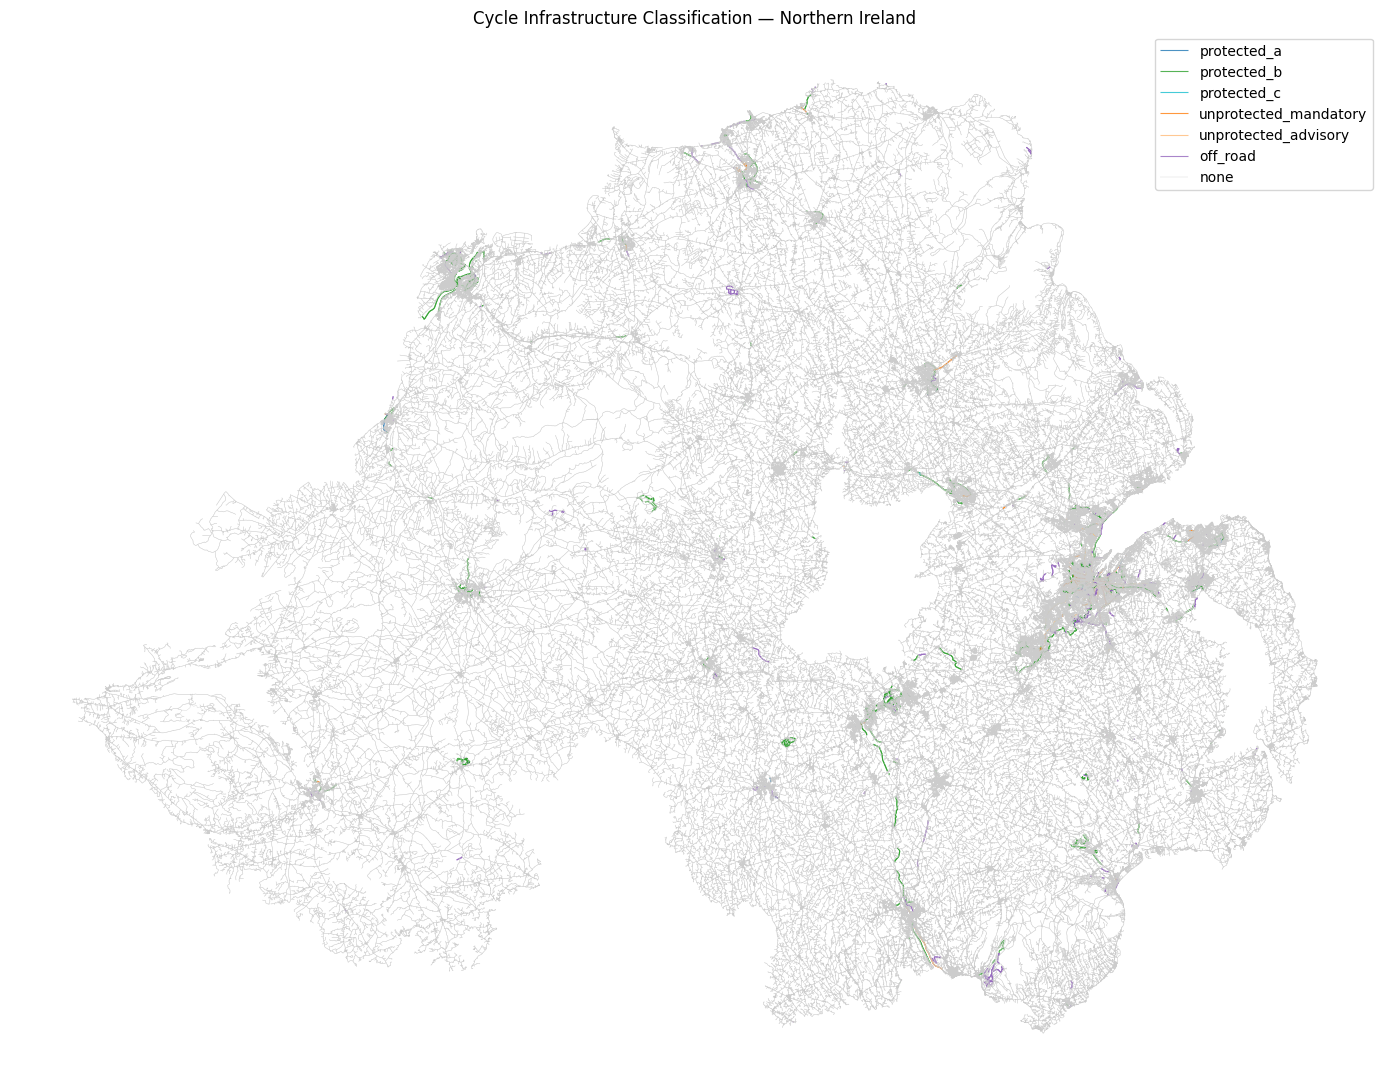

In [15]:
colour_map = {
    'protected_a': '#1f77b4',
    'protected_b': '#2ca02c',
    'protected_c': '#17becf',
    'unprotected_mandatory': '#ff7f0e',
    'unprotected_advisory': '#ffbb78',
    'off_road': '#9467bd',
    'none': '#cccccc',
}

fig, ax = plt.subplots(figsize=(14, 14))
for cat, colour in colour_map.items():
    subset = edges[edges['cycle_infra'] == cat]
    if len(subset) > 0:
        subset.plot(ax=ax, color=colour,
                    linewidth=0.8 if cat != 'none' else 0.3,
                    label=cat, alpha=0.8)

ax.legend(loc='upper right')
ax.set_title('Cycle Infrastructure Classification — Northern Ireland')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'NI_cycle_infrastructure.png', dpi=300, bbox_inches='tight')
plt.show()

## Level of Traffic Stress (LTS) — Augmented Conveyal Scheme

The [Conveyal Estimated LTS scheme](https://docs.conveyal.com/learn-more/traffic-stress) is a sequential rule-based implementation of Mekuria et al. (2012), adapted for contexts where only standard OpenStreetMap tags are available. Jeong & Smith (2025) augment this with three improvements:

1. **Full network coverage** via Routino fallback for unclassified edges (especially `highway=service`)
2. **Cycle infrastructure override** — protected infrastructure takes precedence over road class
3. **Signalised junction adjustment** — reduces intersection stress where traffic signals are present

### Pipeline execution order

| Step | Function | Description |
|------|----------|-------------|
| 1 | `get_speed_kmh()` | Parse OSM speed tags |
| 2 | `calculate_lts()` | Base Conveyal per-edge classification |
| 3 | `is_cyclable()` | Filter non-cyclable edges |
| 4 | `apply_cycle_infra_override()` | Protected infrastructure → LTS 1–2 |
| 5 | `apply_routino_fallback()` | Fill remaining unclassified edges |
| 6 | `apply_conveyal_intersection_adjustment()` | Max-LTS propagation at unsignalised junctions |
| 7 | `apply_jeong_smith_intersection()` | Signal-aware intersection adjustment |

Steps 4–5 run **before** Steps 6–7 to ensure every edge has a valid baseline LTS before the intersection propagation pass.

### Extract traffic signal locations

Traffic signal nodes are needed for the Jeong & Smith signalised intersection adjustment (Step 7). These are extracted via OSMnx from the Overpass API.

In [16]:
# Extract traffic signal nodes from OSM via Overpass
traffic_signals = ox.features_from_polygon(
    study_area_4326.union_all(),
    tags={'highway': 'traffic_signals'}
)

if traffic_signals is not None and len(traffic_signals) > 0:
    traffic_signals = traffic_signals.to_crs(CRS_IG)
    # Keep only point geometries (nodes, not ways)
    traffic_signals = traffic_signals[traffic_signals.geometry.geom_type == 'Point']
    print(f"Traffic signal nodes: {len(traffic_signals):,}")
else:
    print("WARNING: No traffic signals found. Step 7 will be skipped.")
    traffic_signals = None

Traffic signal nodes: 3,142


In [17]:
# Count intersections and signal coverage
def geom_to_endpoints(geom):
    if geom.geom_type == 'MultiLineString':
        coords_start = list(geom.geoms[0].coords)
        coords_end   = list(geom.geoms[-1].coords)
        start = tuple(np.round(coords_start[0], 2))
        end   = tuple(np.round(coords_end[-1], 2))
    else:
        coords = list(geom.coords)
        start  = tuple(np.round(coords[0],  2))
        end    = tuple(np.round(coords[-1], 2))
    return start, end

endpoints = edges['geometry'].apply(geom_to_endpoints)
all_nodes = []
for start, end in endpoints:
    all_nodes.append(start)
    all_nodes.append(end)

node_counts     = Counter(all_nodes)
total_nodes     = len(node_counts)
intersections   = {n: c for n, c in node_counts.items() if c >= 3}
n_intersections = len(intersections)

print(f"Total unique nodes          : {total_nodes:,}")
print(f"True intersections (deg >= 3): {n_intersections:,}")
if traffic_signals is not None:
    print(f"Signal coverage             : {len(traffic_signals) / n_intersections * 100:.1f}%")

Total unique nodes          : 479,043
True intersections (deg >= 3): 313,659
Signal coverage             : 1.0%


In [18]:
# =============================================================================
# AUGMENTED CONVEYAL LTS PIPELINE — Northern Ireland Cycling Network
# =============================================================================

# ── Constants ──
SPEED_THRESHOLD_KMH = 25 * 1.609   # 25 mph -> ~40.23 km/h
LANE_THRESHOLD      = 3
MISSING_LANES       = 999

NO_CAR_HIGHWAYS = {
    'cycleway', 'path', 'footway', 'pedestrian', 'track', 'bridleway'
}

ROUTINO_FALLBACK_LTS = {
    'cycleway': 1, 'path': 1, 'track': 1, 'living_street': 1,
    'footway': 1, 'pedestrian': 1,
    'service': 2, 'bridleway': 2,
    'steps': 3, 'secondary': 3,
    'primary': 4, 'primary_link': 4, 'trunk': 4, 'trunk_link': 4,
}


# ── Step 1: Speed parser ──
def get_speed_kmh(maxspeed_tag):
    if pd.isna(maxspeed_tag) or str(maxspeed_tag).strip() == '':
        return np.nan
    s = str(maxspeed_tag).lower().strip()
    m = re.match(r'^([0-9][\.0-9]*?) ?(km/h|kmh|kph|mph|knots)?$', s)
    if not m:
        return np.nan
    val, unit = float(m.group(1)), m.group(2)
    if unit == 'mph':    return val * 1.609
    if unit == 'knots':  return val * 1.852
    return val


# ── Step 2: Base Conveyal per-edge LTS classifier ──
def calculate_lts(row):
    highway     = str(row.get('highway', '') or '').lower().strip()
    cycle_infra = str(row.get('cycle_infra', 'none') or 'none').lower().strip()

    if highway in NO_CAR_HIGHWAYS:                  return 1
    if highway == 'service':                        return None
    if highway in ('residential', 'living_street'): return 1

    speed_kmh = get_speed_kmh(row.get('maxspeed'))
    try:
        lanes = int(float(row.get('lanes'))) if pd.notnull(row.get('lanes')) else MISSING_LANES
    except (ValueError, TypeError):
        lanes = MISSING_LANES

    slow_road     = (not np.isnan(speed_kmh)) and (speed_kmh <= SPEED_THRESHOLD_KMH)
    unknown_speed = np.isnan(speed_kmh)
    few_lanes     = lanes <= LANE_THRESHOLD
    unknown_lanes = lanes == MISSING_LANES

    default_lts = 3
    if slow_road and (few_lanes or unknown_lanes):  default_lts = 2
    elif few_lanes and unknown_speed:               default_lts = 2

    if highway in ('unclassified', 'tertiary', 'tertiary_link'):
        if unknown_lanes and slow_road:   default_lts = 2
        if cycle_infra in ('protected_a', 'unprotected_mandatory', 'unprotected_advisory'):
            return 2
        return default_lts

    if cycle_infra in ('protected_a', 'unprotected_mandatory', 'unprotected_advisory'):
        return default_lts

    return 4


# ── Step 3: Cyclability filter ──
def is_cyclable(row):
    highway = str(row.get('highway', '') or '').lower().strip()
    if highway in {'motorway', 'motorway_link', 'proposed', 'construction',
                   'abandoned', 'platform'}:
        return False
    service_type = str(row.get('service', '') or '').lower().strip()
    if highway == 'service' and service_type in {
        'parking_aisle', 'driveway', 'drive-through', 'car_wash', 'garages'}:
        return False
    if str(row.get('bicycle', '') or '').lower().strip() in ('no', 'private', 'restricted'):
        return False
    return True


# ── Step 4: Jeong & Smith cycle infrastructure override ──
def apply_cycle_infra_override(edges):
    ci = edges['cycle_infra'].str.lower().str.strip()
    fully_protected = ci.isin(['protected_b', 'protected_c', 'off_road'])
    adjacent_track  = ci == 'protected_a'
    edges.loc[fully_protected, 'lts'] = 1
    edges.loc[adjacent_track,  'lts'] = 2
    print(f"  protected_b/c/off_road -> LTS 1 : {fully_protected.sum():,} edges")
    print(f"  protected_a            -> LTS 2 : {adjacent_track.sum():,} edges")
    return edges


# ── Step 5: Routino highway fallback ──
def apply_routino_fallback(edges):
    mask = edges['lts'].isna()
    if mask.sum() == 0:
        print("  No unclassified edges.")
        return edges
    fallback = edges.loc[mask, 'highway'].str.lower().str.strip().map(ROUTINO_FALLBACK_LTS)
    edges.loc[mask, 'lts'] = fallback
    print(f"  Filled : {fallback.notna().sum():,}  |  Still NaN : {edges['lts'].isna().sum():,}")
    return edges


# ── Step 6: Conveyal intersection adjustment ──
def apply_conveyal_intersection_adjustment(edges):
    def ep(geom):
        if geom.geom_type == 'MultiLineString':
            return (tuple(np.round(list(geom.geoms[0].coords)[0], 2)),
                    tuple(np.round(list(geom.geoms[-1].coords)[-1], 2)))
        c = list(geom.coords)
        return tuple(np.round(c[0], 2)), tuple(np.round(c[-1], 2))

    ve = defaultdict(list)
    for idx, row in edges.iterrows():
        s, e = ep(row.geometry)
        ve[s].append(idx); ve[e].append(idx)

    intersections = {c: e for c, e in ve.items() if len(e) >= 3}
    edges      = edges.copy()
    lts_series = edges['lts'].copy()
    n_upgraded = 0

    for _, edge_idxs in intersections.items():
        vals = [lts_series[i] for i in edge_idxs if pd.notnull(lts_series[i])]
        if not vals: continue
        mx = max(vals)
        for i in edge_idxs:
            if pd.notnull(lts_series[i]) and mx > lts_series[i]:
                lts_series[i] = mx; n_upgraded += 1

    edges['lts'] = lts_series
    print(f"  Intersections : {len(intersections):,}  |  Edges upgraded : {n_upgraded:,}")
    return edges


# ── Step 7: Jeong & Smith signalised intersection adjustment ──
def apply_jeong_smith_intersection(edges, traffic_signals, signal_buffer_m=15.0):
    def ep(geom):
        if geom.geom_type == 'MultiLineString':
            return (tuple(np.round(list(geom.geoms[0].coords)[0], 2)),
                    tuple(np.round(list(geom.geoms[-1].coords)[-1], 2)))
        c = list(geom.coords)
        return tuple(np.round(c[0], 2)), tuple(np.round(c[-1], 2))

    ve = defaultdict(list)
    for idx, row in edges.iterrows():
        s, e = ep(row.geometry)
        ve[s].append(idx); ve[e].append(idx)

    intersections  = {c: e for c, e in ve.items() if len(e) >= 3}
    sig_geoms      = traffic_signals.geometry.values
    sig_sindex     = traffic_signals.sindex

    def is_signalised(xy):
        pt = Point(xy)
        cands = list(sig_sindex.intersection(pt.buffer(signal_buffer_m).bounds))
        return any(sig_geoms[i].distance(pt) <= signal_buffer_m for i in cands)

    edges      = edges.copy()
    lts_series = edges['lts'].copy()
    n_unsig = n_sig = n_reduced = 0

    for coord, edge_idxs in intersections.items():
        vals = [lts_series[i] for i in edge_idxs if pd.notnull(lts_series[i])]
        if not vals: continue
        mx = max(vals)

        if is_signalised(coord):
            n_sig += 1
            mn = min(vals)
            if mx <= 2:                    jlts = 1;      n_reduced += 1
            elif mn <= 2 and mx >= 3:      jlts = mx - 1; n_reduced += 1
            else:                          jlts = mx
        else:
            n_unsig += 1; jlts = mx

        for i in edge_idxs:
            if pd.notnull(lts_series[i]) and jlts > lts_series[i]:
                lts_series[i] = jlts

    edges['lts'] = lts_series
    print(f"  Intersections : {len(intersections):,}")
    print(f"  Unsignalised  : {n_unsig:,}  |  Signalised : {n_sig:,}  |  Reduced : {n_reduced:,}")
    return edges


# ── Helper ──
def print_lts_dist(edges, mask, label):
    d = edges.loc[mask, 'lts'].value_counts().sort_index()
    print(f"\n-- {label} --")
    for k in [1.0, 2.0, 3.0, 4.0]:
        print(f"  LTS {int(k)} : {d.get(k,0):>8,}")
    print(f"  None  : {edges.loc[mask,'lts'].isna().sum():>8,}")


# ── Execute Pipeline ──

# Step 2: Base Conveyal per-edge labelling
edges['lts'] = np.nan
cyclable_mask = edges.apply(is_cyclable, axis=1)
edges.loc[cyclable_mask, 'lts'] = edges[cyclable_mask].apply(calculate_lts, axis=1)
print(f"Cyclable edges : {cyclable_mask.sum():,}  |  "
      f"Labeled : {edges.loc[cyclable_mask,'lts'].notna().sum():,}  |  "
      f"Unlabeled : {edges.loc[cyclable_mask,'lts'].isna().sum():,}")
print_lts_dist(edges, cyclable_mask, "Step 2 - Base Conveyal per-edge")

# Step 4: Cycle infrastructure override
print("\n-- Step 4 - Jeong & Smith cycle infrastructure override --")
edges = apply_cycle_infra_override(edges)

# Step 5: Routino highway fallback
print("\n-- Step 5 - Routino highway fallback --")
edges = apply_routino_fallback(edges)
print_lts_dist(edges, cyclable_mask, "After Steps 4+5 (Pre-Intersection Baseline)")

# Save snapshot before intersection passes
edges['lts_pre_intersection'] = edges['lts'].copy()

# Step 6: Conveyal intersection adjustment (for comparison)
print("\n-- Step 6 - Conveyal intersection adjustment --")
edges_conveyal = apply_conveyal_intersection_adjustment(edges.copy())
edges['lts_conveyal_intersection'] = edges_conveyal['lts']
print_lts_dist(edges, cyclable_mask, "After Step 6 - Strict Conveyal intersection")

# Step 7: Jeong & Smith signalised intersection adjustment
if traffic_signals is not None and len(traffic_signals) > 0:
    print("\n-- Step 7 - Jeong & Smith signalised intersection adjustment --")
    edges['lts'] = edges['lts_pre_intersection'].copy()
    edges = apply_jeong_smith_intersection(edges, traffic_signals)
    print_lts_dist(edges, cyclable_mask, "After Step 7 - Jeong & Smith intersection")
else:
    print("\nStep 7 skipped — no traffic signal data available.")
    edges['lts'] = edges['lts_conveyal_intersection'].copy()

# Diagnostic comparison
conveyal_d = edges.loc[cyclable_mask, 'lts_conveyal_intersection'].value_counts().sort_index()
jeong_d    = edges.loc[cyclable_mask, 'lts'].value_counts().sort_index()
print(f"\n-- Diagnostics: Conveyal vs Jeong & Smith --")
print(f"{'LTS':<8} {'Conveyal':>10} {'Jeong&Smith':>12} {'Change':>10}")
print("-" * 44)
for k in [1.0, 2.0, 3.0, 4.0]:
    c = conveyal_d.get(k, 0); j = jeong_d.get(k, 0)
    print(f"LTS {int(k):<4} {c:>10,} {j:>12,} {j-c:>+10,}")

Cyclable edges : 949,464  |  Labeled : 716,858  |  Unlabeled : 232,606

-- Step 2 - Base Conveyal per-edge --
  LTS 1 :  416,028
  LTS 2 :   27,257
  LTS 3 :  166,830
  LTS 4 :  106,743
  None  :  232,606

-- Step 4 - Jeong & Smith cycle infrastructure override --
  protected_b/c/off_road -> LTS 1 : 11,762 edges
  protected_a            -> LTS 2 : 256 edges

-- Step 5 - Routino highway fallback --
  Filled : 393,047  |  Still NaN : 609

-- After Steps 4+5 (Pre-Intersection Baseline) --
  LTS 1 :  416,023
  LTS 2 :  259,985
  LTS 3 :  166,734
  LTS 4 :  106,722
  None  :        0

-- Step 6 - Conveyal intersection adjustment --
  Intersections : 313,659  |  Edges upgraded : 737,419

-- After Step 6 - Strict Conveyal intersection --
  LTS 1 :  416,023
  LTS 2 :  259,985
  LTS 3 :  166,734
  LTS 4 :  106,722
  None  :        0

-- Step 7 - Jeong & Smith signalised intersection adjustment --
  Intersections : 313,659
  Unsignalised  : 307,836  |  Signalised : 5,698  |  Reduced : 4,301

-- 

### LTS map

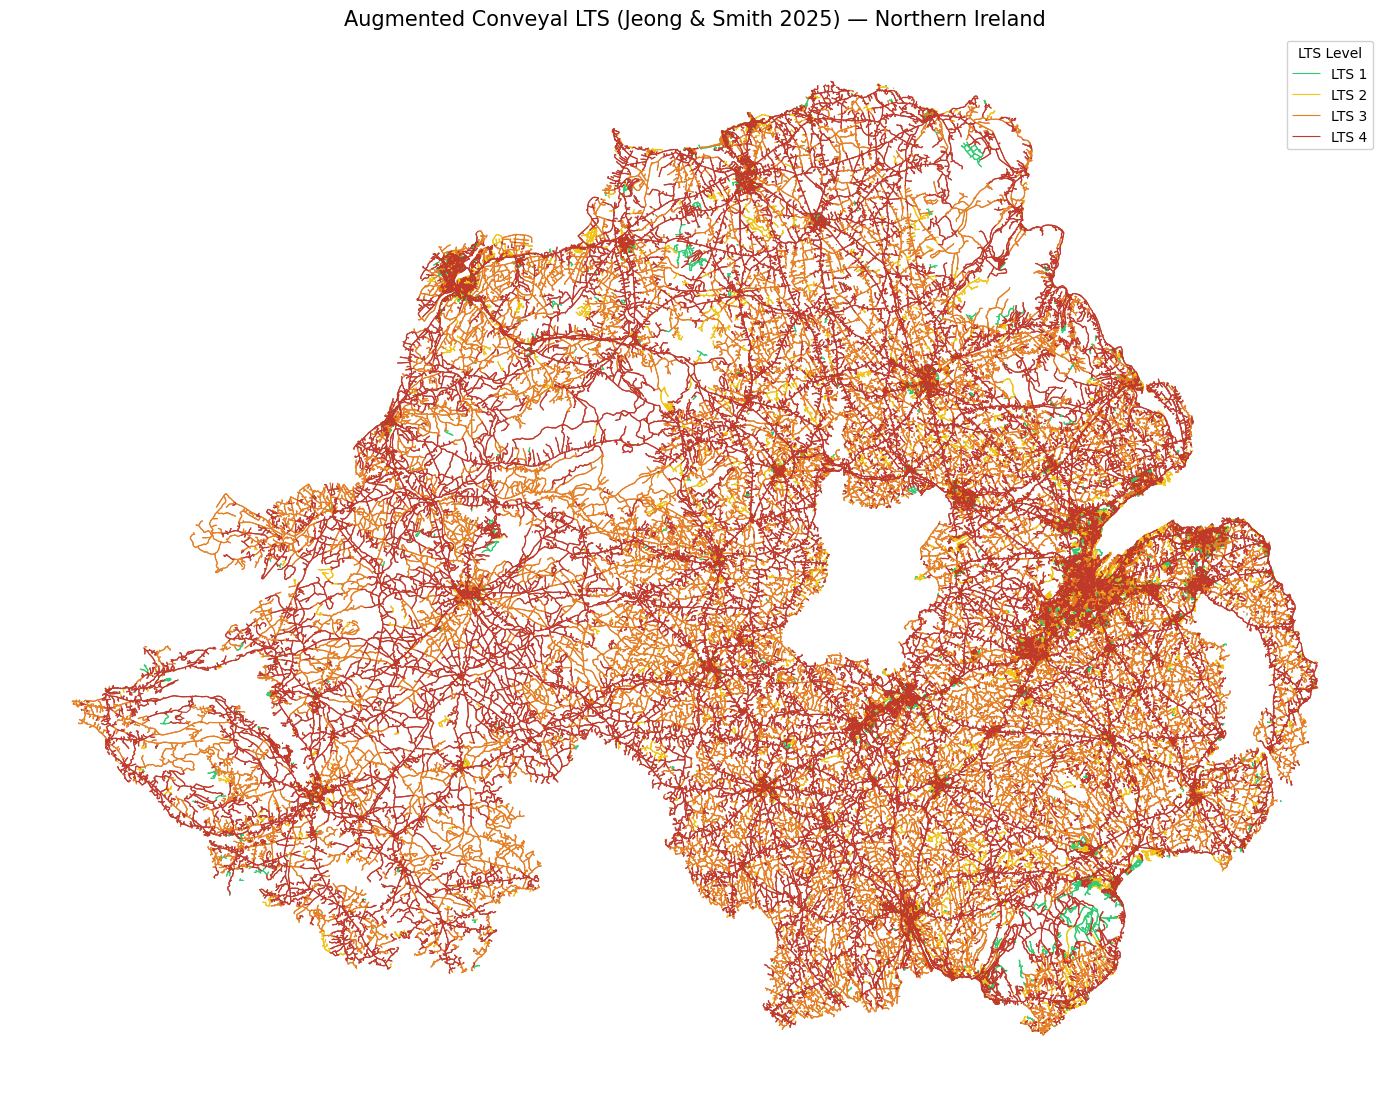

In [19]:
plot_gdf = edges[edges.apply(is_cyclable, axis=1)].copy()
plot_gdf['lts_status'] = plot_gdf['lts'].apply(
    lambda x: f"LTS {int(x)}" if pd.notnull(x) else "Missing"
)

fig, ax = plt.subplots(1, 1, figsize=(14, 14))
plot_gdf.plot(ax=ax, color='#eeeeee', linewidth=0.5, zorder=1)

color_map = {
    'LTS 1': '#2ecc71',
    'LTS 2': '#f1c40f',
    'LTS 3': '#e67e22',
    'LTS 4': '#c0392b',
    'Missing': '#9b59b6',
}
for status, color in color_map.items():
    subset = plot_gdf[plot_gdf['lts_status'] == status]
    if not subset.empty:
        subset.plot(ax=ax, color=color, linewidth=0.8, label=status,
                    zorder=3 if status == 'Missing' else 2)

ax.set_title("Augmented Conveyal LTS (Jeong & Smith 2025) — Northern Ireland", fontsize=15)
ax.legend(title="LTS Level", loc='upper right', framealpha=0.9)
ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'NI_LTS_map.png', dpi=300, bbox_inches='tight')
plt.show()

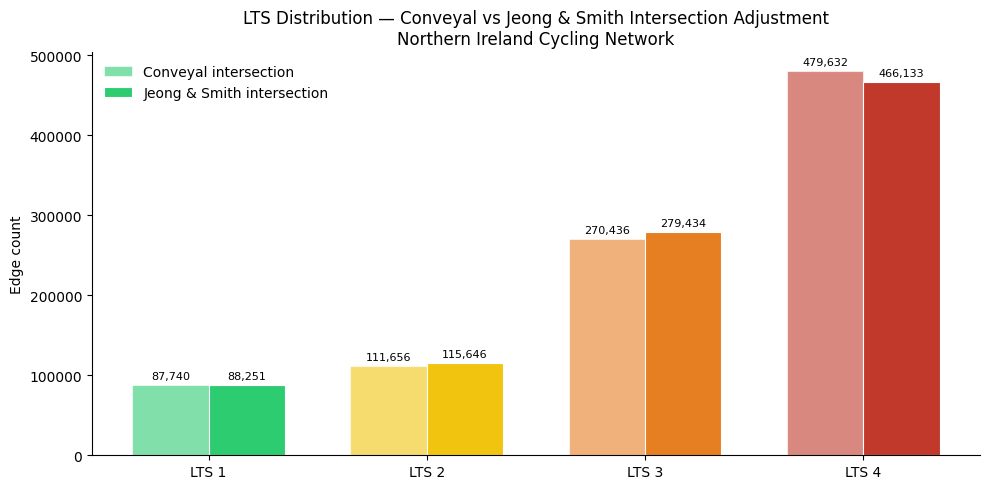

In [20]:
cyclable_mask = edges.apply(is_cyclable, axis=1)

lts_keys   = [1.0, 2.0, 3.0, 4.0]
lts_labels = ['LTS 1', 'LTS 2', 'LTS 3', 'LTS 4']
colors     = ['#2ecc71', '#f1c40f', '#e67e22', '#c0392b']

conveyal_counts = [edges.loc[cyclable_mask, 'lts_conveyal_intersection'].value_counts().get(k, 0) for k in lts_keys]
jeong_counts    = [edges.loc[cyclable_mask, 'lts'].value_counts().get(k, 0) for k in lts_keys]

x, width = np.arange(len(lts_labels)), 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_c = ax.bar(x - width/2, conveyal_counts, width,
                label='Conveyal intersection', color=colors, alpha=0.6,
                edgecolor='white', linewidth=0.8)
bars_j = ax.bar(x + width/2, jeong_counts, width,
                label='Jeong & Smith intersection', color=colors,
                edgecolor='white', linewidth=0.8)

for bar, val in zip(bars_c, conveyal_counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(conveyal_counts)*0.01,
            f'{val:,}', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars_j, jeong_counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(jeong_counts)*0.01,
            f'{val:,}', ha='center', va='bottom', fontsize=8)

ax.set_title('LTS Distribution — Conveyal vs Jeong & Smith Intersection Adjustment\nNorthern Ireland Cycling Network')
ax.set_ylabel('Edge count')
ax.set_xticks(x)
ax.set_xticklabels(lts_labels)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'NI_LTS_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Export LTS-labelled network

Save the final LTS-labelled network as GeoParquet for downstream use in Conveyal or other routing/accessibility tools.

In [ ]:
# Select columns relevant for downstream analysis
export_cols = [
    'u', 'v', 'key', 'osmid', 'highway', 'maxspeed', 'name', 'oneway',
    'length', 'lanes', 'ref', 'geometry',
    'cycle_infra', 'lts', 'lts_per_edge', 'lts_pre_intersection',
    'lts_conveyal_intersection',
]

# Keep only columns that exist
export_cols = [c for c in export_cols if c in edges.columns]

# Add any cycling-specific columns
for col in ['cycleway', 'cycleway:left', 'cycleway:right', 'cycleway:both',
            'bicycle', 'surface', 'segregated', 'lit']:
    if col in edges.columns and col not in export_cols:
        export_cols.append(col)

edges_export = edges[export_cols].copy()

# Fix mixed types for Parquet
for col in edges_export.select_dtypes(include='object').columns:
    if col != 'geometry':
        edges_export[col] = edges_export[col].astype(str)
edges_export = edges_export.replace('nan', np.nan)

edges_export.to_parquet(DATA_DIR / "ni_cycling_network_lts.parquet")
print(f"Exported {len(edges_export):,} edges with LTS labels")
print(f"Saved to {DATA_DIR / 'ni_cycling_network_lts.parquet'}")